<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Karyawan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

# 1️⃣ --- Cek apakah GPU aktif di Colab ---
import os
gpu_info = os.popen('nvidia-smi').read()
if "failed" in gpu_info:
    print("⚠️ GPU belum aktif. Aktifkan via Runtime > Change runtime type > GPU")
else:
    print("✅ GPU aktif dan siap dipakai!")
    print(gpu_info.split('\n')[0])

# 2️⃣ --- Cara 1: Pakai %%time (khusus untuk cell di Colab) ---
# Jalankan ini di satu cell Colab terpisah:
# %%time
# for i in range(10_000_000):
#     _ = i ** 2

# 3️⃣ --- Cara 2: Pakai time.time() manual ---
import time

print("\n⏱️ Mengukur waktu dengan time.time() ...")
start = time.time()
for i in range(10_000_000):
    _ = i ** 2
end = time.time()
print(f"Waktu eksekusi loop biasa: {end - start:.3f} detik")

# 4️⃣ --- Cara 3: Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()  # pertama kali akan kompilasi (lebih lambat)
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()  # eksekusi berikutnya super cepat
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")

# 5️⃣ --- Cara 4: Gunakan operasi vectorized (NumPy) ---
import numpy as np

print("\n⚙️ Mengukur waktu dengan operasi vectorized NumPy ...")
start = time.time()
x = np.arange(10_000_000)
y = x ** 2  # super cepat tanpa loop manual
end = time.time()
print(f"Waktu eksekusi NumPy: {end - start:.3f} detik")

# 6️⃣ --- Bonus: Decorator otomatis untuk mengukur waktu fungsi ---
def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏰ Fungsi '{func.__name__}' selesai dalam {end - start:.3f} detik")
        return result
    return wrapper

@timed
def contoh_fungsi():
    s = 0
    for i in range(5_000_000):
        s += i ** 2
    return s

print("\n🧩 Contoh fungsi dengan decorator otomatis:")
contoh_fungsi()

✅ GPU aktif dan siap dipakai!


⏱️ Mengukur waktu dengan time.time() ...
Waktu eksekusi loop biasa: 2.690 detik

⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 5.051 detik
Eksekusi berikutnya: 0.000 detik

⚙️ Mengukur waktu dengan operasi vectorized NumPy ...
Waktu eksekusi NumPy: 0.096 detik

🧩 Contoh fungsi dengan decorator otomatis:
⏰ Fungsi 'contoh_fungsi' selesai dalam 1.759 detik


41666654166667500000

**Load Dataset**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [7]:
data = pd.read_csv("/content/HR.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

# Removed redundant display(data.head()) here as it's already shown above.
# print("\nPreview data after initial loading and duplicate handling:")
# display(data.head())

# Filter columns based on user's request (keep the listed features)
columns_to_keep = [
    'OverTime', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
    'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'Age', 'JobInvolvement', 'Attrition',
    'Department'
]

# Ensure all columns to keep are actually in the DataFrame
existing_columns = data.columns.tolist()
valid_columns_to_keep = [col for col in columns_to_keep if col in existing_columns]

if len(valid_columns_to_keep) != len(columns_to_keep):
    print("\nWarning: Some specified columns to keep were not found in the DataFrame.")
    print(f"Original list: {columns_to_keep}")
    print(f"Actual columns kept: {valid_columns_to_keep}")

data = data[valid_columns_to_keep]

print("\nData after feature selection (keeping specified columns):")
display(data.head())
print("\nNew columns after selection:")
print(data.columns.tolist())

Preview data:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel   

,OverTime,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,Age,JobInvolvement,Attrition,Department
0,Yes,5993,2,8,6,1,4,2,41,3,Yes,Sales
1,No,5130,2,10,10,8,2,3,49,2,No,Research & Development
2,Yes,2090,1,7,0,2,3,4,37,2,Yes,Research & Development
3,Yes,2909,1,8,8,3,3,4,33,3,No,Research & Development
4,No,3468,1,6,2,2,2,1,27,3,No,Research & Development



New columns after selection:
['OverTime', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction', 'EnvironmentSatisfaction', 'Age', 'JobInvolvement', 'Attrition', 'Department']


**Correlation Matrix**

In [8]:
import numpy as np

# Buat salinan data agar perubahan tidak mempengaruhi DataFrame asli
data_for_correlation = data.copy()

# Ubah kolom 'Attrition' dan 'OverTime' dari kategorikal ('Yes'/'No') menjadi numerik (1/0)
data_for_correlation['Attrition'] = data_for_correlation['Attrition'].map({'Yes': 1, 'No': 0})
data_for_correlation['OverTime'] = data_for_correlation['OverTime'].map({'Yes': 1, 'No': 0})

# Pilih hanya kolom numerik untuk perhitungan korelasi
numerical_cols = data_for_correlation.select_dtypes(include=[np.number])

# Hitung matriks korelasi
correlation_matrix = numerical_cols.corr()

print("Matriks Korelasi:")
display(correlation_matrix)

Matriks Korelasi:


,OverTime,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,Age,JobInvolvement,Attrition
OverTime,1.000000,0.006089,0.000544,0.012754,-0.011687,0.025514,0.024539,0.070132,0.028062,-0.003507,0.246118
MonthlyIncome,0.006089,1.000000,0.950300,0.772893,0.514285,-0.017014,-0.007157,-0.006259,0.497855,-0.015271,-0.159840
JobLevel,0.000544,0.950300,1.000000,0.782208,0.534739,0.005303,-0.001944,0.001212,0.509604,-0.012630,-0.169105
TotalWorkingYears,0.012754,0.772893,0.782208,1.000000,0.628133,0.004628,-0.020185,-0.002693,0.680381,-0.005533,-0.171063
YearsAtCompany,-0.011687,0.514285,0.534739,0.628133,1.000000,0.009508,-0.003803,0.001458,0.311309,-0.021355,-0.134392
DistanceFromHome,0.025514,-0.017014,0.005303,0.004628,0.009508,1.000000,-0.003669,-0.016075,-0.001686,0.008783,0.077924
JobSatisfaction,0.024539,-0.007157,-0.001944,-0.020185,-0.003803,-0.003669,1.000000,-0.006784,-0.004892,-0.021476,-0.103481
EnvironmentSatisfaction,0.070132,-0.006259,0.001212,-0.002693,0.001458,-0.016075,-0.006784,1.000000,0.010146,-0.008278,-0.103369
Age,0.028062,0.497855,0.509604,0.680381,0.311309,-0.001686,-0.004892,0.010146,1.000000,0.029820,-0.159205
JobInvolvement,-0.003507,-0.015271,-0.012630,-0.005533,-0.021355,0.008783,-0.021476,-0.008278,0.029820,1.000000,-0.130016


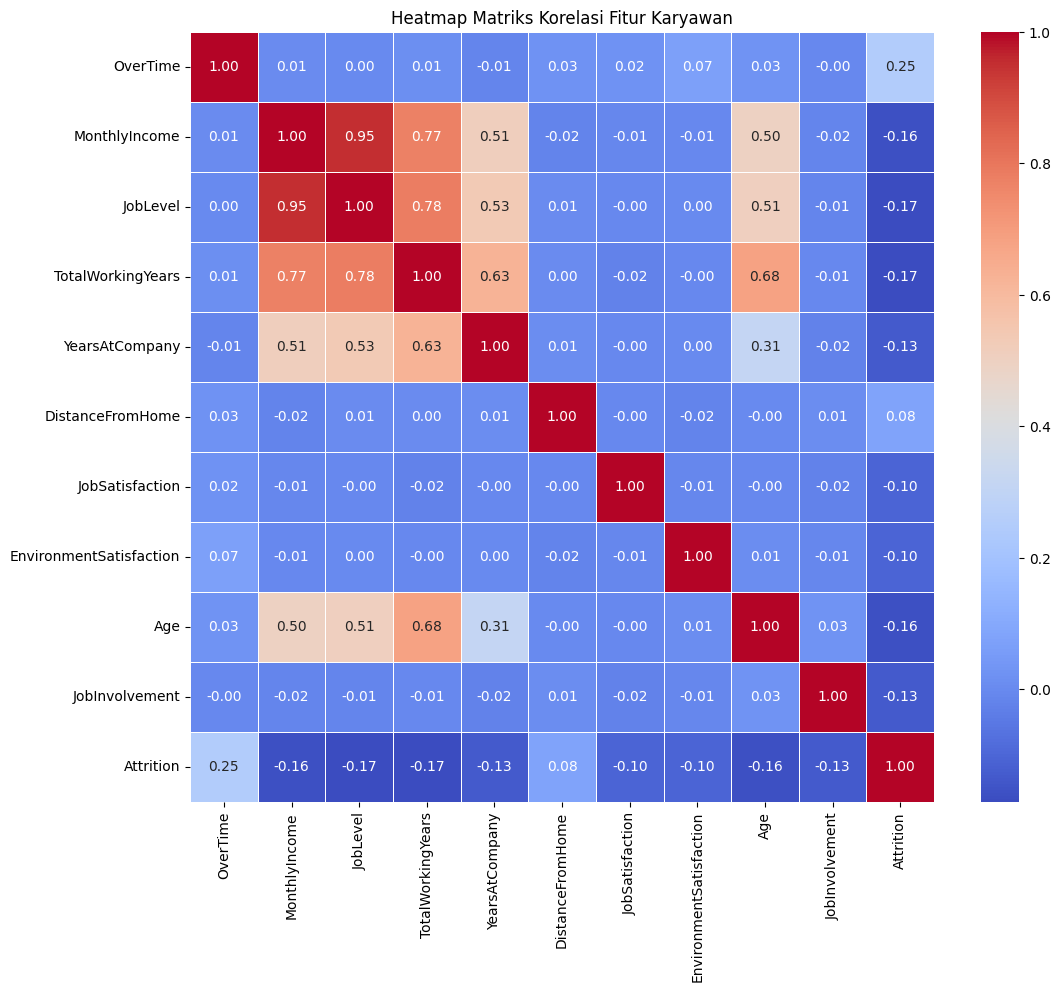

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Matriks Korelasi Fitur Karyawan')
plt.show()

**Encoding Kolom Kategorikal**

In [11]:
# Ubah kolom 'Attrition' dan 'OverTime' dari kategorikal ('Yes'/'No') menjadi numerik (1/0)
data['Attrition'] = data['Attrition'].map({'Yes': 1, 'No': 0})
data['OverTime'] = data['OverTime'].map({'Yes': 1, 'No': 0})

print("Data setelah konversi 'Attrition' dan 'OverTime' ke numerik:")
display(data.head())

# Lakukan One-Hot Encoding untuk kolom 'Department'
data = pd.get_dummies(data, columns=['Department'], drop_first=True)

print("\nData setelah One-Hot Encoding untuk 'Department':")
display(data.head())

print("\nInfo kolom setelah encoding:")
print(data.info())

Data setelah konversi 'Attrition' dan 'OverTime' ke numerik:


,OverTime,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,Age,JobInvolvement,Attrition,Department
0,1,5993,2,8,6,1,4,2,41,3,1,Sales
1,0,5130,2,10,10,8,2,3,49,2,0,Research & Development
2,1,2090,1,7,0,2,3,4,37,2,1,Research & Development
3,1,2909,1,8,8,3,3,4,33,3,0,Research & Development
4,0,3468,1,6,2,2,2,1,27,3,0,Research & Development



Data setelah One-Hot Encoding untuk 'Department':


,OverTime,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,Age,JobInvolvement,Attrition,Department_Research & Development,Department_Sales
0,1,5993,2,8,6,1,4,2,41,3,1,False,True
1,0,5130,2,10,10,8,2,3,49,2,0,True,False
2,1,2090,1,7,0,2,3,4,37,2,1,True,False
3,1,2909,1,8,8,3,3,4,33,3,0,True,False
4,0,3468,1,6,2,2,2,1,27,3,0,True,False



Info kolom setelah encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   OverTime                           1470 non-null   int64
 1   MonthlyIncome                      1470 non-null   int64
 2   JobLevel                           1470 non-null   int64
 3   TotalWorkingYears                  1470 non-null   int64
 4   YearsAtCompany                     1470 non-null   int64
 5   DistanceFromHome                   1470 non-null   int64
 6   JobSatisfaction                    1470 non-null   int64
 7   EnvironmentSatisfaction            1470 non-null   int64
 8   Age                                1470 non-null   int64
 9   JobInvolvement                     1470 non-null   int64
 10  Attrition                          1470 non-null   int64
 11  Department_Research & Development  1470 non-null   b

**Split Data**

In [14]:
y = data['Attrition']
X = data.drop('Attrition', axis=1)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nX_train (5 baris pertama):")
print(X_train[:5])
print("\nX_test (5 baris pertama):")
print(X_test[:5])
print("\ny_train (5 elemen pertama):")
print(y_train[:5])
print("\ny_test (5 elemen pertama):")
print(y_test[:5])


X_train (5 baris pertama):
      OverTime  MonthlyIncome  JobLevel  TotalWorkingYears  YearsAtCompany  \
1194         0          15972         4                 29               3   
128          0           2523         1                  3               2   
810          0          17465         4                 23              12   
478          0           2096         1                  7               7   
491          1           5679         2                 10               8   

      DistanceFromHome  JobSatisfaction  EnvironmentSatisfaction  Age  \
1194                 2                2                        2   47   
128                  2                4                        3   22   
810                  3                3                        1   46   
478                 13                3                        2   25   
491                  9                3                        4   43   

      JobInvolvement  Department_Research & Development  Departm

**Standardisasi**

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Penerapan Feature Engineering dan Encoding Fitur Kategori**

In [16]:
import numpy as np

def apply_feature_engineering(df):
    df_copy = df.copy()

    # Feature 1: Experience Ratio (Years at Company relative to Total Working Years)
    # Replace 0 in TotalWorkingYears with 1 to avoid division by zero
    df_copy['TotalWorkingYears_eff'] = df_copy['TotalWorkingYears'].replace(0, 1)
    df_copy['Experience_Ratio'] = df_copy['YearsAtCompany'] / df_copy['TotalWorkingYears_eff']
    df_copy.drop(columns=['TotalWorkingYears_eff'], inplace=True)

    # Feature 2: Monthly Income per Job Level
    # JobLevel is expected to be >= 1, so no division by zero handling needed based on info
    df_copy['Income_Per_Level'] = df_copy['MonthlyIncome'] / df_copy['JobLevel']

    # Feature 3: Interaction between Age and MonthlyIncome
    df_copy['Age_x_MonthlyIncome'] = df_copy['Age'] * df_copy['MonthlyIncome']

    return df_copy

# Simpan nama kolom asli sebelum feature engineering untuk perbandingan
original_X_train_cols = X_train.columns.tolist()

# Apply feature engineering to X_train and X_test
X_train = apply_feature_engineering(X_train)
X_test = apply_feature_engineering(X_test)

print("X_train setelah Feature Engineering (5 baris pertama):")
display(X_train.head())

print("\nFitur-fitur baru yang ditambahkan:")
print(X_train.columns.difference(original_X_train_cols).tolist())

X_train setelah Feature Engineering (5 baris pertama):


,OverTime,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,Age,JobInvolvement,Department_Research & Development,Department_Sales,Experience_Ratio,Income_Per_Level,Age_x_MonthlyIncome
1194,0,15972,4,29,3,2,2,2,47,4,False,True,0.103448,3993.00,750684
128,0,2523,1,3,2,2,4,3,22,3,True,False,0.666667,2523.00,55506
810,0,17465,4,23,12,3,3,1,46,3,False,True,0.521739,4366.25,803390
478,0,2096,1,7,7,13,3,2,25,3,False,True,1.000000,2096.00,52400
491,1,5679,2,10,8,9,3,4,43,3,True,False,0.800000,2839.50,244197



Fitur-fitur baru yang ditambahkan:
['Age_x_MonthlyIncome', 'Experience_Ratio', 'Income_Per_Level']


**Penskalaan Data**

In [18]:
from sklearn.preprocessing import StandardScaler

scaler_original = StandardScaler()
X_train_original_scaled = scaler_original.fit_transform(X_train)
X_test_original_scaled = scaler_original.transform(X_test)

print("Data asli berhasil diskalakan!")

Data asli berhasil diskalakan!


**Pelatihan Model Regresi Logistik**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Logistic Regression
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # Gunakan solver 'liblinear' karena cocok untuk dataset kecil dan L1/L2 regularization

# Latih model menggunakan data training yang sudah diskalakan
logistic_model.fit(X_train_original_scaled, y_train)

print("==============================================")
print("Model Logistic Regression berhasil dilatih.")
print("==============================================")
print()

Model Logistic Regression berhasil dilatih.



In [22]:
# Lakukan prediksi pada data testing yang sudah diskalakan
y_pred_logistic = logistic_model.predict(X_test_original_scaled)

print("\nEvaluasi Model Logistic Regression:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_logistic):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))


Evaluasi Model Logistic Regression:
Accuracy Score: 0.8776

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.79      0.32      0.45        47

    accuracy                           0.88       294
   macro avg       0.84      0.65      0.69       294
weighted avg       0.87      0.88      0.85       294



**ROC Curve dan AUC Score**

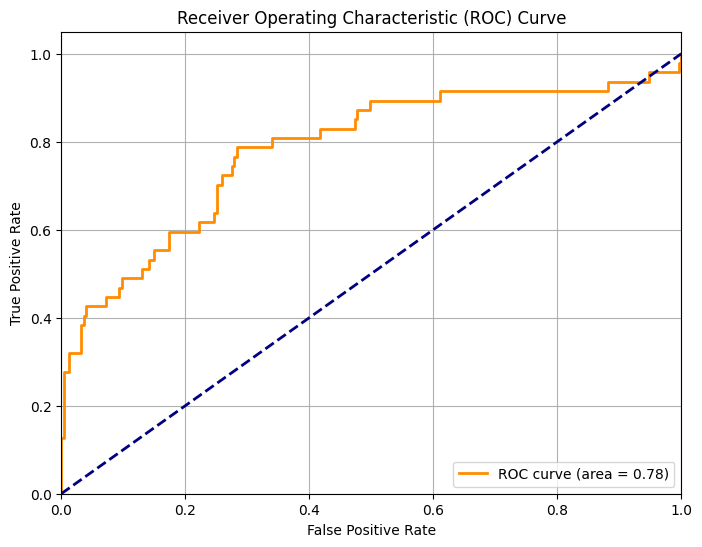

AUC Score for Logistic Regression Model: 0.7825


In [23]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Dapatkan probabilitas prediksi untuk kelas positif (Attrition = 1)
y_pred_proba = logistic_model.predict_proba(X_test_original_scaled)[:, 1]

# Hitung ROC curve (FPR dan TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Hitung AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC Score for Logistic Regression Model: {roc_auc:.4f}")

**Koefisien Fitur Model Regresi Logistik**

In [24]:
import pandas as pd

# Dapatkan koefisien fitur dari model
coefficients = logistic_model.coef_[0]

# Dapatkan nama-nama fitur dari X_train
feature_names = X_train.columns

# Buat DataFrame untuk menampilkan koefisien fitur
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Tambahkan intercept ke DataFrame
intercept_df = pd.DataFrame({
    'Feature': ['Intercept'],
    'Coefficient': [logistic_model.intercept_[0]]
})

coef_df = pd.concat([coef_df, intercept_df], ignore_index=True)

print("Koefisien Fitur Model Regresi Logistik:")
display(coef_df.sort_values(by='Coefficient', ascending=False))

Koefisien Fitur Model Regresi Logistik:


,Feature,Coefficient
14,Age_x_MonthlyIncome,1.444489
0,OverTime,0.668139
5,DistanceFromHome,0.285625
11,Department_Sales,0.154619
4,YearsAtCompany,0.081001
10,Department_Research & Development,-0.218877
1,MonthlyIncome,-0.225071
12,Experience_Ratio,-0.261919
6,JobSatisfaction,-0.337293
9,JobInvolvement,-0.367069


Membuat histogram/KDE plots untuk distribusi fitur numerik...


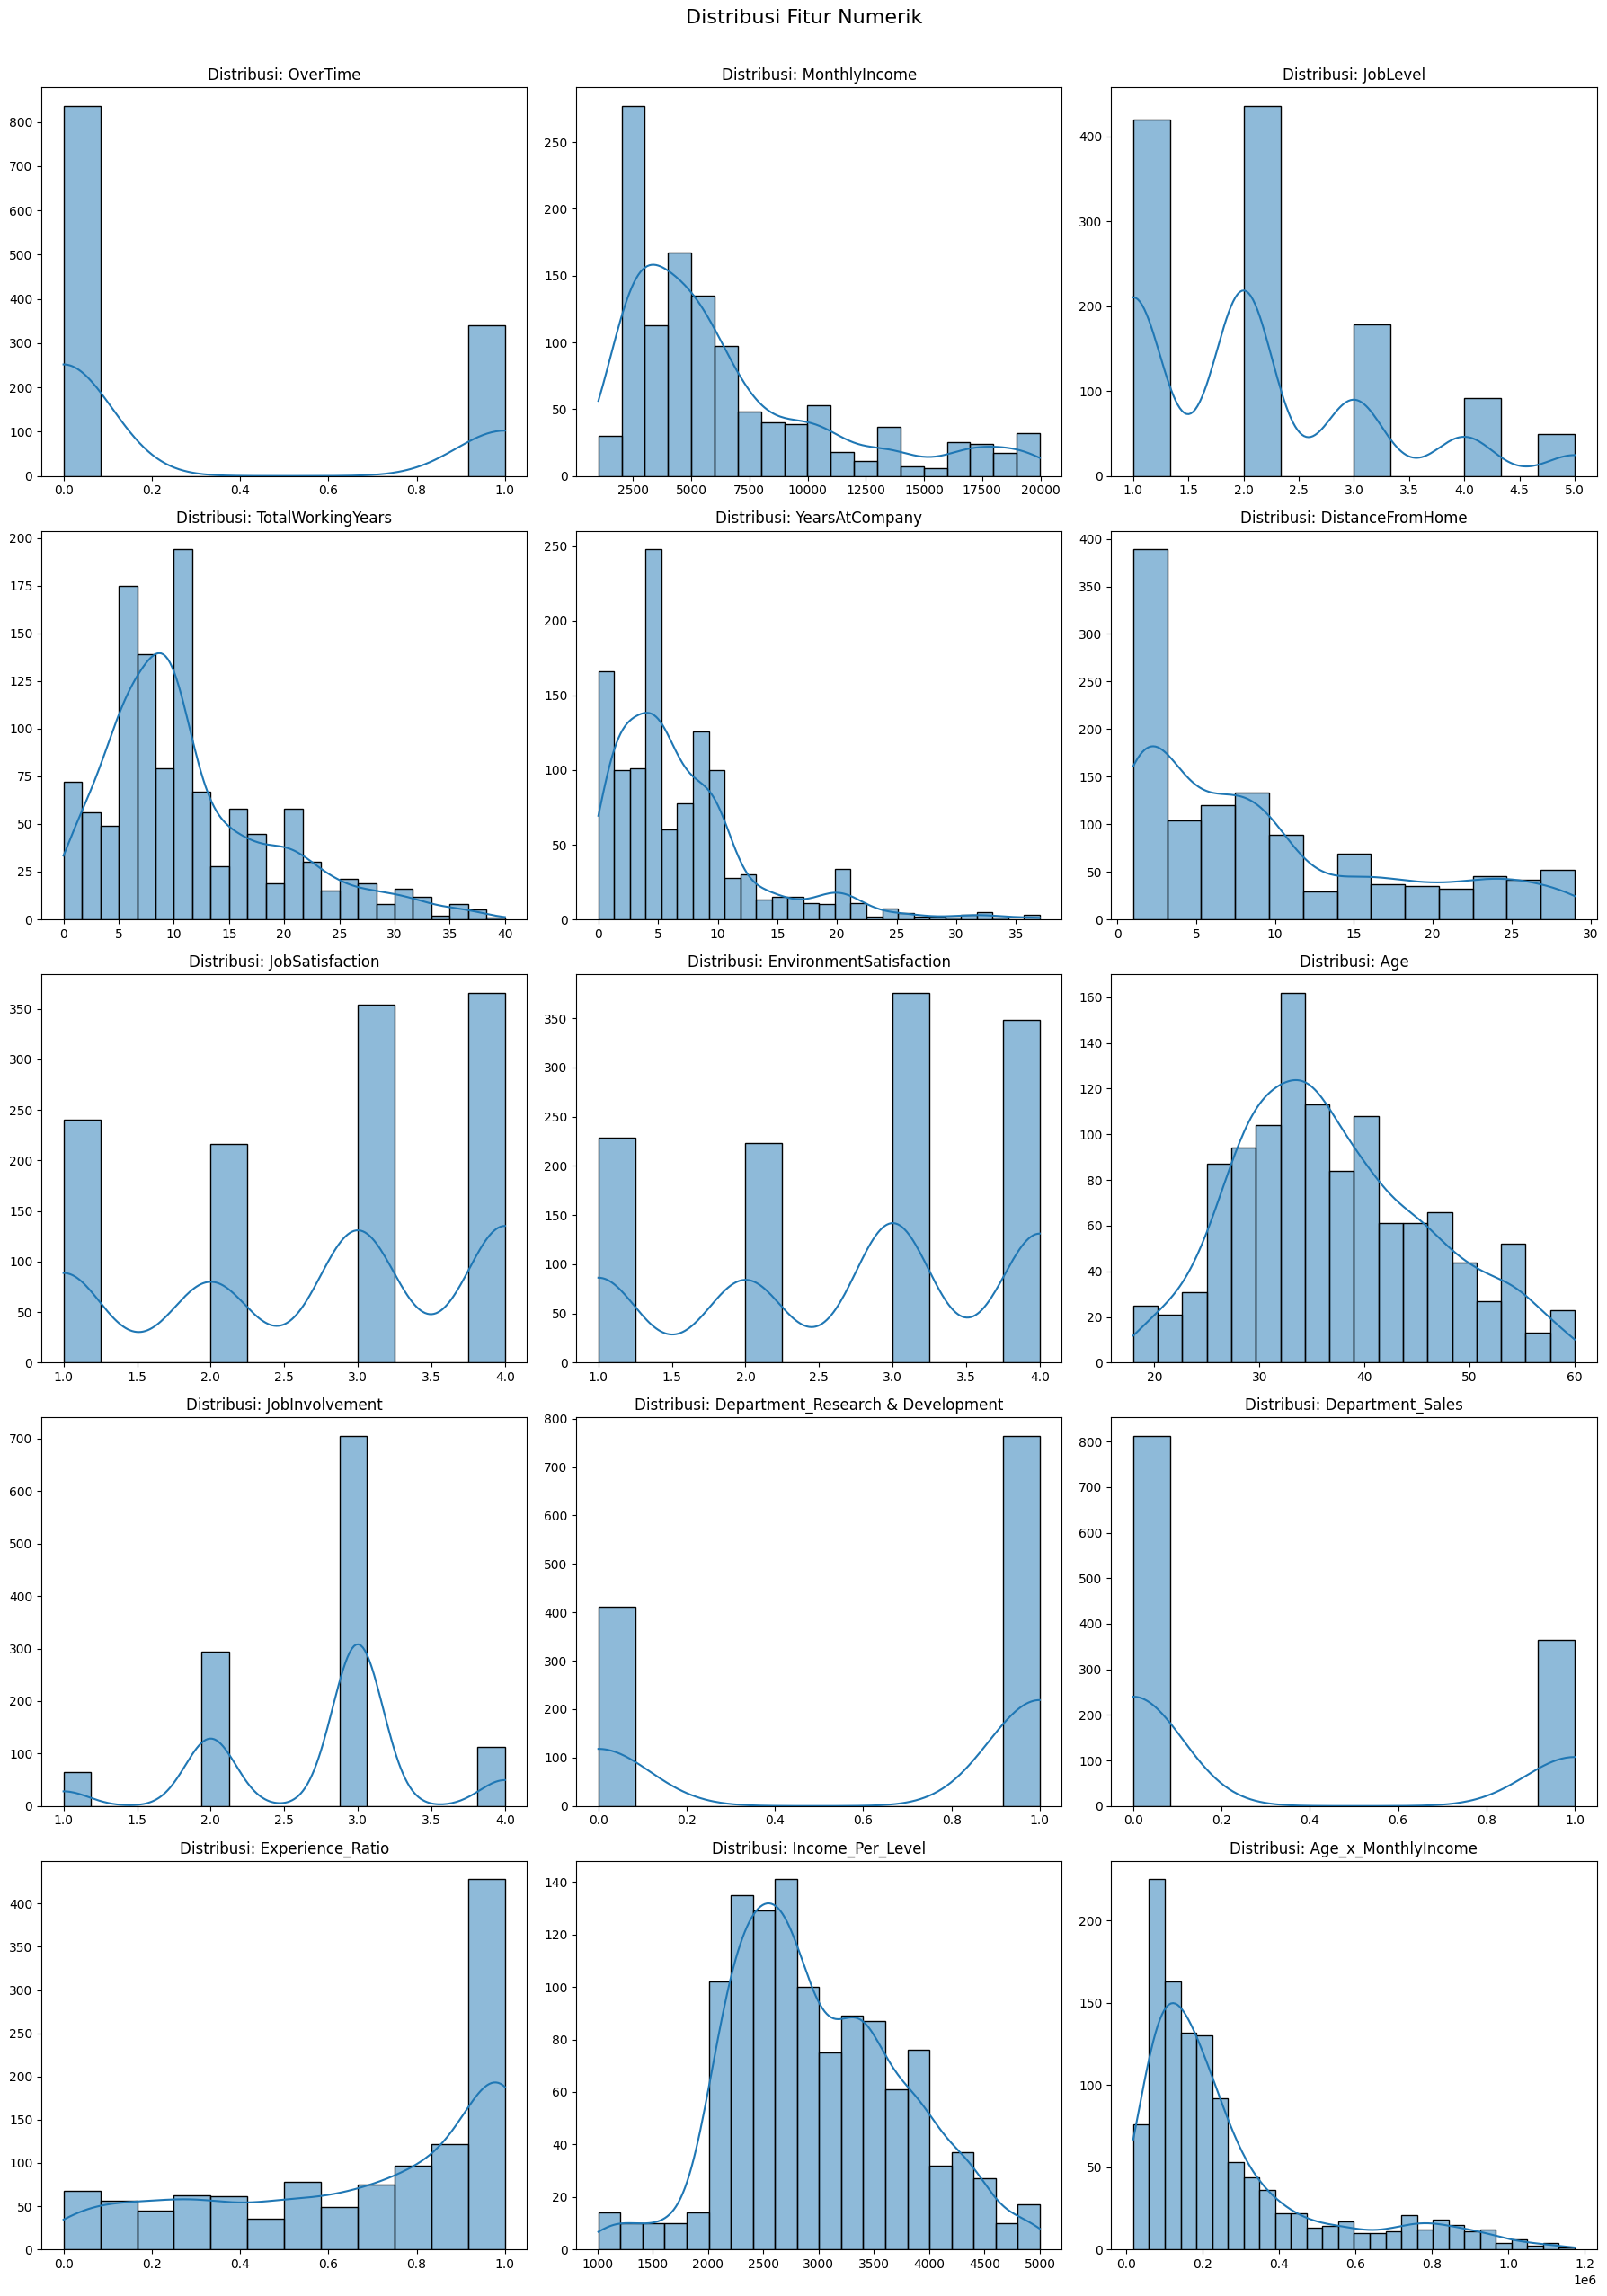

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gabungkan X_train dan y_train untuk visualisasi
# Pastikan index dari X_train dan y_train sejajar
df_combined = X_train.copy()
df_combined['Attrition'] = y_train

# Identifikasi kolom numerik (termasuk fitur baru dan biner 0/1)
numerical_features = df_combined.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()
# Kecualikan Attrition dari daftar fitur yang akan diplot distribusinya sendiri
if 'Attrition' in numerical_features:
    numerical_features.remove('Attrition')

print("Membuat histogram/KDE plots untuk distribusi fitur numerik...")
# Plot distribusi fitur numerik
fig1, axes1 = plt.subplots(nrows=len(numerical_features) // 3 + (len(numerical_features) % 3 > 0), ncols=3, figsize=(18, 5 * (len(numerical_features) // 3 + (len(numerical_features) % 3 > 0))))
axes1 = axes1.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df_combined[col], kde=True, ax=axes1[i])
    axes1[i].set_title(f'Distribusi: {col}')
    axes1[i].set_xlabel('')
    axes1[i].set_ylabel('')

plt.tight_layout()
plt.suptitle('Distribusi Fitur Numerik', y=1.02, fontsize=16)
plt.show()

**Distribusi Target Attrition (left)**

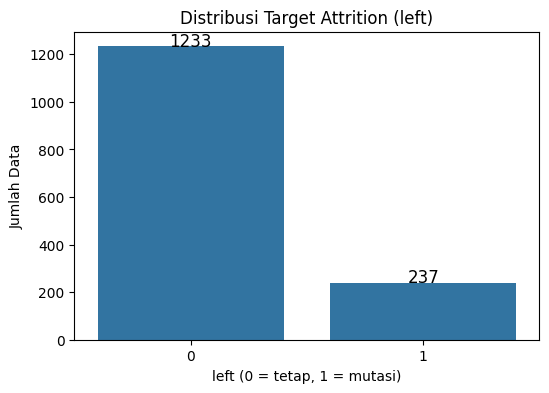

In [29]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y)
plt.title("Distribusi Target Attrition (left)")
plt.xlabel("left (0 = tetap, 1 = mutasi)")
plt.ylabel("Jumlah Data")

# Tambahkan angka di atas bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 2,
        f'{int(height)}',
        ha="center",
        fontsize=12,
        color="black"
    )

plt.show()

Membuat box plots untuk memeriksa hubungan fitur numerik dengan Attrition...


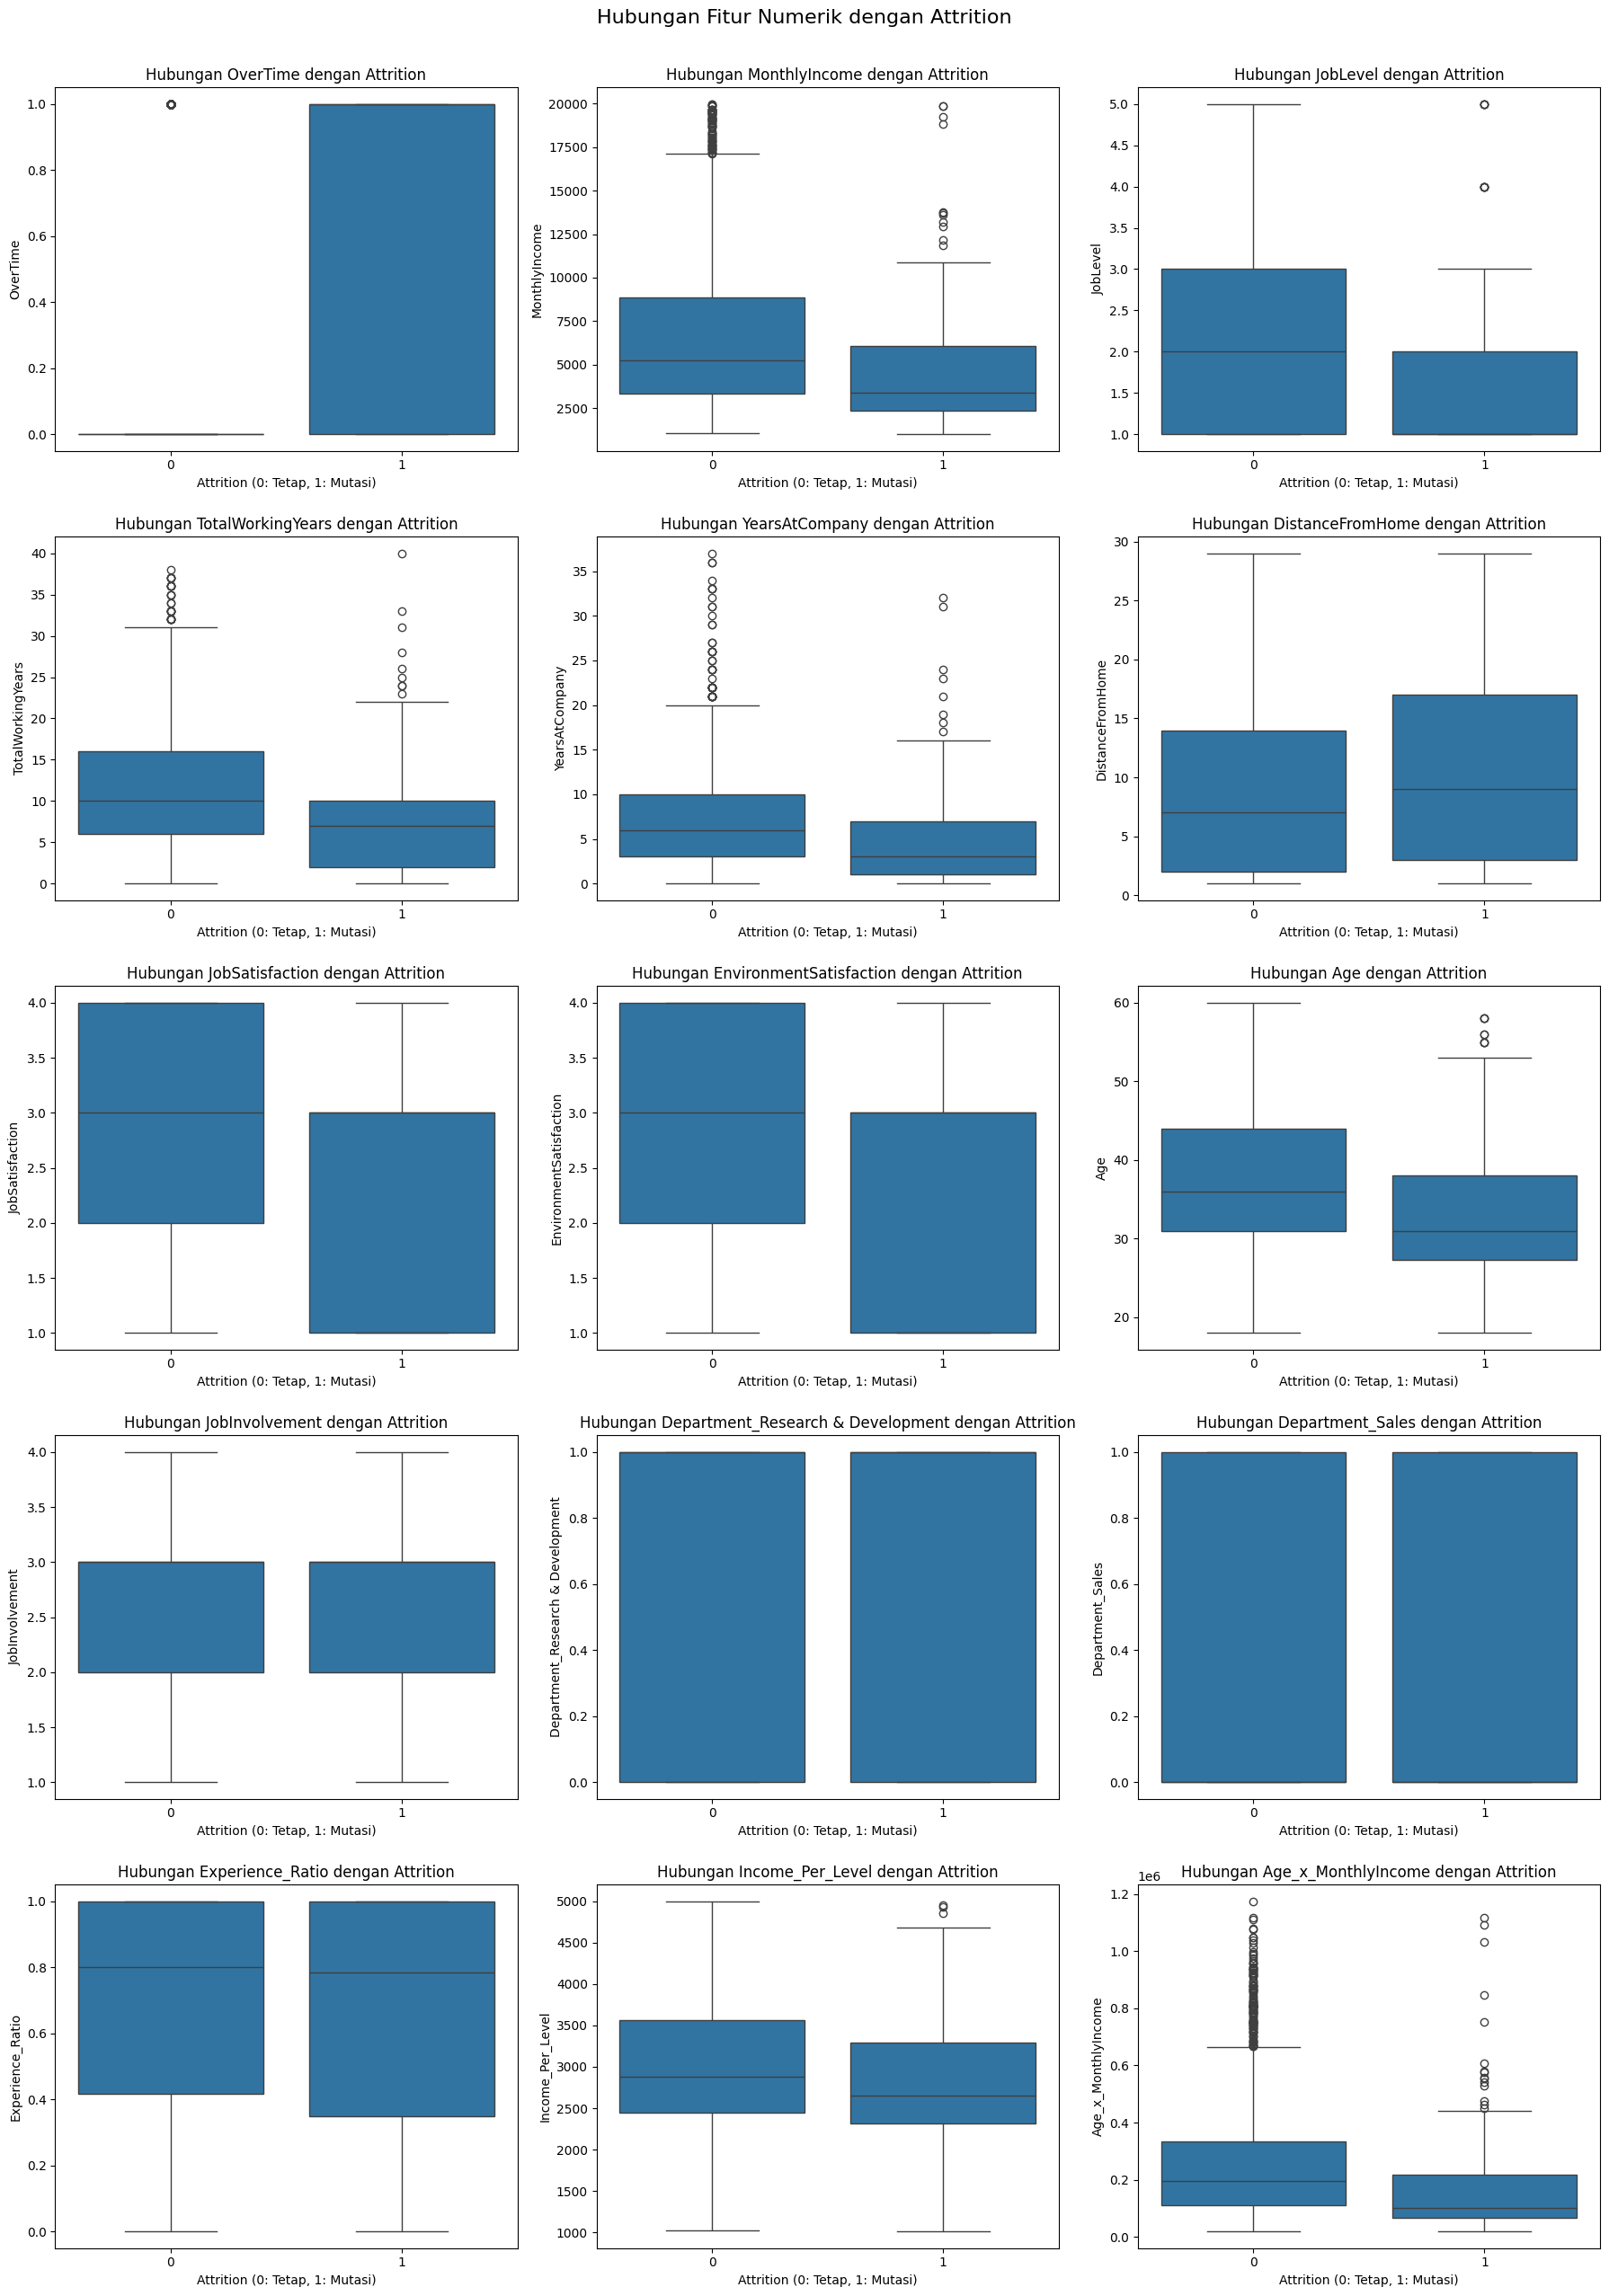

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gabungkan X_train dan y_train untuk visualisasi
# Pastikan index dari X_train dan y_train sejajar
df_combined = X_train.copy()
df_combined['Attrition'] = y_train

# Identifikasi kolom numerik (termasuk fitur baru dan biner 0/1)
numerical_features = df_combined.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()
# Kecualikan Attrition dari daftar fitur yang akan diplot distribusinya sendiri
if 'Attrition' in numerical_features:
    numerical_features.remove('Attrition')

print("Membuat box plots untuk memeriksa hubungan fitur numerik dengan Attrition...")
# Plot box plot untuk melihat hubungan dengan Attrition (linearitas informal)
fig2, axes2 = plt.subplots(nrows=len(numerical_features) // 3 + (len(numerical_features) % 3 > 0), ncols=3, figsize=(18, 5 * (len(numerical_features) // 3 + (len(numerical_features) % 3 > 0))))
axes2 = axes2.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x='Attrition', y=col, data=df_combined, ax=axes2[i])
    axes2[i].set_title(f'Hubungan {col} dengan Attrition')
    axes2[i].set_xlabel('Attrition (0: Tetap, 1: Mutasi)')
    axes2[i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Hubungan Fitur Numerik dengan Attrition', y=1.02, fontsize=16)
plt.show()

**Korelasi dengan target (Atrition)**

Top 5 Fitur Paling Berpengaruh Terhadap Attrition:


,feature,correlation_with_attrition
0,OverTime,0.246118
1,TotalWorkingYears,-0.171063
2,JobLevel,-0.169105
3,MonthlyIncome,-0.159840
4,Age,-0.159205


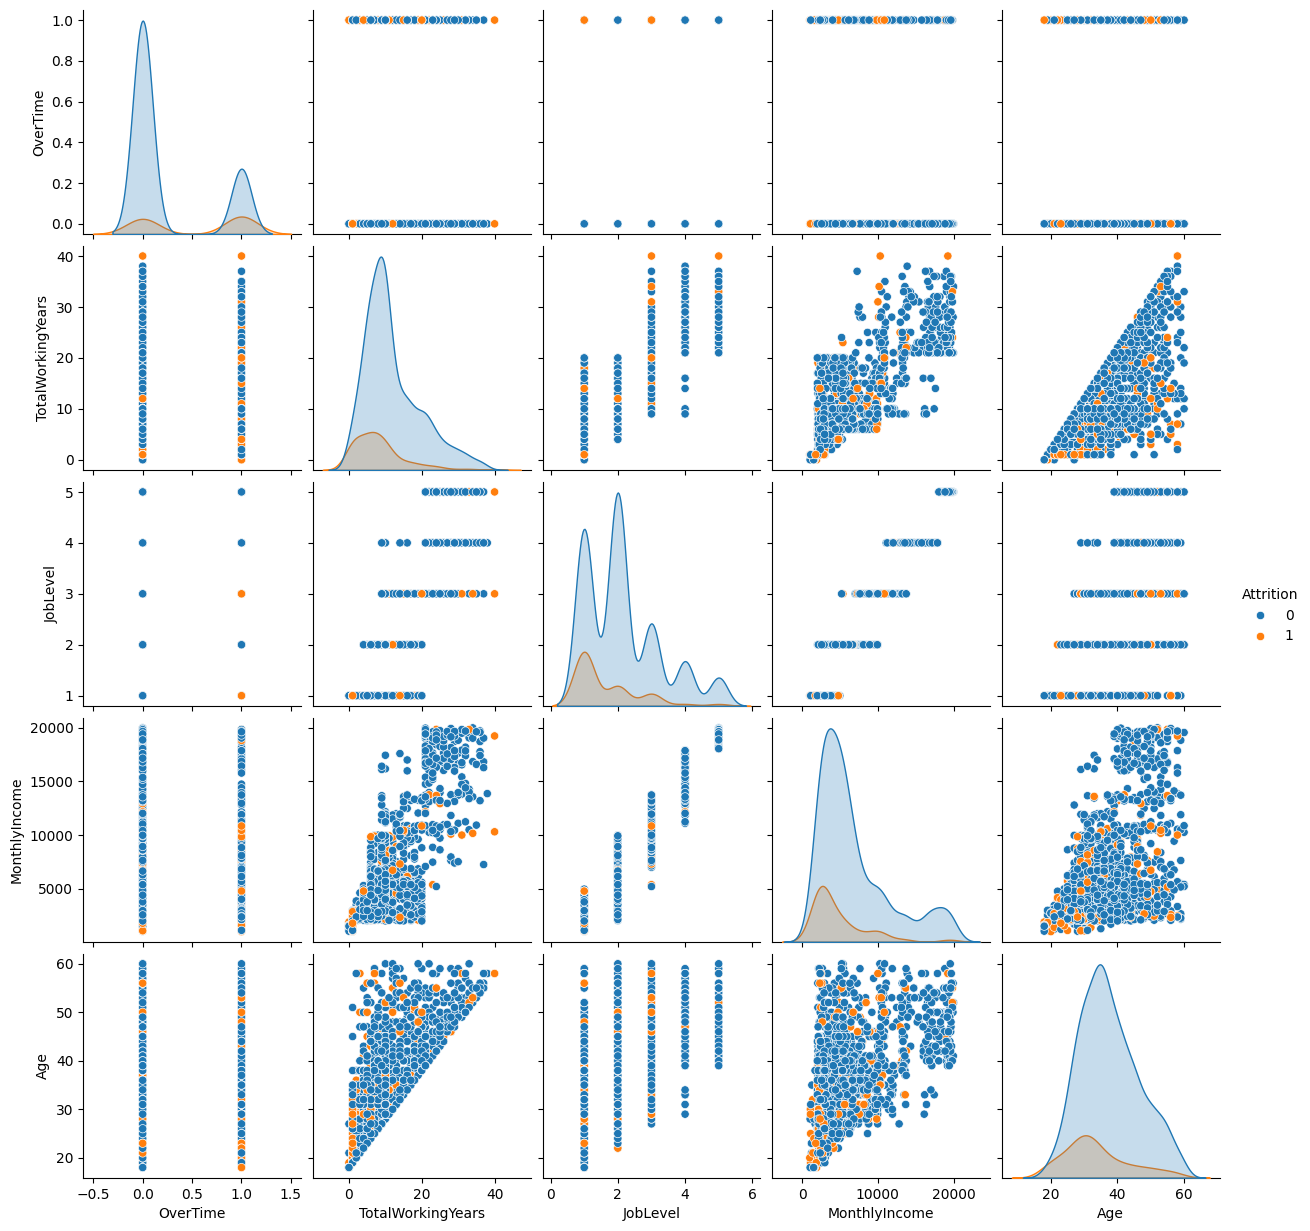

In [33]:
# Hitung korelasi dengan target (Attrition)
# Tambahkan numeric_only=True untuk memastikan hanya kolom numerik yang digunakan
corr_target = data.corr(numeric_only=True)['Attrition'].drop('Attrition')

# Ambil 5 fitur dengan korelasi absolut terbaik
top5_corr = corr_target.abs().sort_values(ascending=False).head(5)
top5_features = top5_corr.index.tolist()

# Tabel ringkas
top5_table = pd.DataFrame({
    'feature': top5_features,
    'correlation_with_attrition': corr_target[top5_features].values
})

print("Top 5 Fitur Paling Berpengaruh Terhadap Attrition:")
display(top5_table)

# Pairplot dengan data (agar kolom cocok)
sns.pairplot(data[top5_features + ['Attrition']], hue='Attrition')